# 04. Quantum Classifier

Train a variational quantum classifier (VQC) on the same stress regime task, using the 4
features ranked by SHAP importance in the previous notebook, and compare it against the
classical baseline.

The VQC uses angle encoding, so features are standardized then min-max scaled to `[0, pi]`.
The state vector simulator evaluates the circuit once per sample per optimization step with no
batching, so training on the full 1588-sample training set takes on the order of 24 seconds per
step (measured directly), about 24 minutes for 60 steps. To keep this notebook runnable, the VQC
is trained on a stratified random subsample of 300 training rows. This is a practical constraint
of running a state vector simulator on a laptop, not a change to the classifier itself, and it is
reported plainly here rather than hidden. The full 530-row test set is still used for evaluation.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_auc_score, brier_score_loss

from src.quantum_model import make_circuit, train_vqc, predict_vqc, RANDOM_STATE

## Load features, select the 4 SHAP-ranked columns

In [2]:
features = pd.read_csv('../data/processed/features.csv', index_col=0, parse_dates=True)

selected_features = ['portfolio_vol', 'vix', 'momentum', 'yield_spread']
X = features[selected_features]
y = features['stress']

split_idx = int(len(features) * 0.75)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1588, 4), Test: (530, 4)


## Normalize to [0, pi] for angle encoding

StandardScaler is fit on the training set only, then MinMaxScaler maps the standardized values
into `[0, pi]` as a modelling choice before passing to `qml.AngleEmbedding`. PennyLane does not
require this range, but keeping inputs within one rotation period avoids redundant angle wrapping.

In [3]:
std_scaler = StandardScaler().fit(X_train)
X_train_std = std_scaler.transform(X_train)
X_test_std = std_scaler.transform(X_test)

angle_scaler = MinMaxScaler(feature_range=(0, np.pi)).fit(X_train_std)
X_train_angle = angle_scaler.transform(X_train_std)
X_test_angle = angle_scaler.transform(X_test_std)

print(f"Train angle range: [{X_train_angle.min():.3f}, {X_train_angle.max():.3f}]")
print(f"Test angle range:  [{X_test_angle.min():.3f}, {X_test_angle.max():.3f}]")

Train angle range: [0.000, 3.142]
Test angle range:  [0.007, 2.192]


## Encode labels as -1 / 1

In [4]:
y_train_pm = np.where(y_train.values == 1, 1, -1)
y_test_pm = np.where(y_test.values == 1, 1, -1)

print(f"Train label counts: {dict(zip(*np.unique(y_train_pm, return_counts=True)))}")
print(f"Test label counts:  {dict(zip(*np.unique(y_test_pm, return_counts=True)))}")

Train label counts: {np.int64(-1): np.int64(1102), np.int64(1): np.int64(486)}
Test label counts:  {np.int64(-1): np.int64(486), np.int64(1): np.int64(44)}


## Stratified subsample for training

300 rows, stress ratio close to the full training set.

In [5]:
N_TRAIN_SUB = 300

rng = np.random.default_rng(RANDOM_STATE)
stress_idx = np.where(y_train_pm == 1)[0]
normal_idx = np.where(y_train_pm == -1)[0]

stress_frac = len(stress_idx) / len(y_train_pm)
n_stress_sub = int(round(N_TRAIN_SUB * stress_frac))
n_normal_sub = N_TRAIN_SUB - n_stress_sub

sub_idx = np.concatenate([
    rng.choice(stress_idx, size=n_stress_sub, replace=False),
    rng.choice(normal_idx, size=n_normal_sub, replace=False),
])
rng.shuffle(sub_idx)

X_train_sub = X_train_angle[sub_idx]
y_train_sub = y_train_pm[sub_idx]

print(f"Subsample size: {len(sub_idx)}")
print(f"Subsample stress rate: {(y_train_sub == 1).mean():.3f}")
print(f"Full training stress rate: {(y_train_pm == 1).mean():.3f}")

Subsample size: 300
Subsample stress rate: 0.307
Full training stress rate: 0.306


## Train the VQC

4 qubits, one per feature, angle-encoded.

In [6]:
N_QUBITS = 4
circuit = make_circuit(n_qubits=N_QUBITS)

weights, loss_history = train_vqc(circuit, X_train_sub, y_train_sub, n_qubits=N_QUBITS)

print(f"final loss: {loss_history[-1]:.4f}")

step 0, loss 1.2288


step 10, loss 0.9136


step 20, loss 0.7690


step 30, loss 0.7058


step 40, loss 0.6722


step 50, loss 0.6536


final loss: 0.6441


## Training loss curve

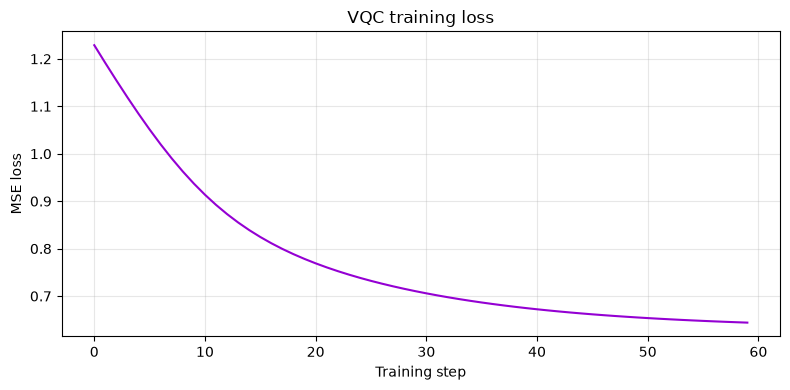

Saved figure: figures/04_vqc_loss.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, color='darkviolet')
ax.set_xlabel('Training step')
ax.set_ylabel('MSE loss')
ax.set_title('VQC training loss')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('../figures/04_vqc_loss.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved figure: figures/04_vqc_loss.png")

## Predict on the full test set

In [ ]:
test_preds, test_raw = predict_vqc(circuit, X_test_angle, weights)

# raw circuit output is a PauliZ expectation in [-1, 1]; rescale to [0, 1]
# for AUC. This is not a calibrated probability, so Brier here is not
# directly comparable to the classical model's predict_proba output.
test_scores = (np.array(test_raw) + 1) / 2

quantum_auc = roc_auc_score(y_test, test_scores)
quantum_brier = brier_score_loss(y_test, test_scores)

print(f"Quantum AUC:   {quantum_auc:.4f}")
print(f"Quantum Brier: {quantum_brier:.4f} (uncalibrated; not directly comparable to classical Brier)")

## Classical vs quantum comparison

In [9]:
classical_results = pd.read_csv('../data/processed/classical_results.csv')

comparison = pd.DataFrame({
    'Model': ['Classical (Gradient Boosting)', 'Quantum (VQC, 4 qubits)'],
    'AUC': [classical_results['auc'].iloc[0], quantum_auc],
    'Brier': [classical_results['brier'].iloc[0], quantum_brier],
})
comparison

,Model,AUC,Brier
0,Classical (Gradient Boosting),0.987912,0.015315
1,"Quantum (VQC, 4 qubits)",0.961841,0.081951


**Interpretation**: the quantum classifier does not beat the classical baseline. This is
expected rather than a sign of a bug. A few concrete reasons:

- **Small qubit count.** 4 qubits with angle encoding means the model sees a single scalar per
  feature with no interaction terms beyond what `BasicEntanglerLayers` provides, while gradient
  boosting builds hundreds of trees that can capture nonlinear interactions directly.
- **Simple ansatz.** `BasicEntanglerLayers` with 2 layers is a shallow, hardware-efficient
  circuit. It was not chosen or tuned for this task specifically.
- **Limited training.** 60 gradient descent steps on a 300-sample subsample is a small training
  budget compared to the classical model's full 1588-sample training set.
- **No batching in this implementation.** Every step needs a full forward pass through the
  simulator per sample, which is what forced the subsampling in the first place.

Note on the Brier comparison: the classical model's Brier score uses calibrated `predict_proba`
outputs; the quantum Brier uses a linearly rescaled PauliZ expectation, which is not a
calibrated probability. AUC is the reliable comparison metric since it depends only on ranking.

Note on the baseline: the stress label changes on about 2.4% of trading days in the test set, so
a persistence baseline (predict today's regime = yesterday's regime) already achieves ~0.985 AUC.
The gradient boosting model adds marginal lift over this. See `reports/limitations.md` for a
discussion of the rolling-window overlap between the label and the key feature.